## Imports

In [41]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.inspection import permutation_importance

## Pfade

In [42]:
DATA_ROOT = Path("../data")

SEGMENTS_PATH = DATA_ROOT / "processed" / "segments_5s_2p5s_index_clean.parquet"
FEAT_BASELINE_PATH = DATA_ROOT / "processed" / "features" / "features_5s_2p5s_clean.parquet"
FEAT_V2_PATH = DATA_ROOT / "processed" / "features" / "features_5s_2p5s_clean_v2.parquet"

TEST_RECORDS_MASTER = DATA_ROOT / "processed" / "models" / "v2" / "test_records_v2.csv"

MODEL_BASELINE_PATH = DATA_ROOT / "processed" / "models" / "rf_tuned_groupcv.joblib"
MODEL_V2_PATH = DATA_ROOT / "processed" / "models" / "v2" / "random_forest_model_v2_tuned_groupcv.joblib"

## Daten laden

In [43]:
segments = pd.read_parquet(SEGMENTS_PATH)
feat_base = pd.read_parquet(FEAT_BASELINE_PATH)
feat_v2 = pd.read_parquet(FEAT_V2_PATH)
test_records = pd.read_csv(TEST_RECORDS_MASTER)

## Gemeinsamer Testsplit (Check)

In [44]:
if test_records.shape[1] == 1:
    test_list = test_records.iloc[:, 0].astype(str).tolist()
else:
    if "source_record" in test_records.columns:
        test_list = test_records["source_record"].astype(str).tolist()
    elif "record" in test_records.columns:
        test_list = test_records["record"].astype(str).tolist()
    else:
        test_list = test_records.iloc[:, 0].astype(str).tolist()

test_set = set(test_list)

segments = segments.copy()
segments["source_record"] = segments["source"].astype(str) + "_" + segments["record"].astype(str)

if any("_" in x for x in test_set):
    seg_test = segments[segments["source_record"].isin(test_set)].copy()
else:
    seg_test = segments[segments["record"].astype(str).isin(test_set)].copy()

merge_keys = ["npz_file", "start_s", "label"]

m_base = seg_test.merge(feat_base, on=merge_keys, how="inner", suffixes=("", "_feat"))
m_v2 = seg_test.merge(feat_v2, on=merge_keys, how="inner", suffixes=("", "_feat"))

m_base["seg_uid"] = m_base["npz_file"].astype(str) + "|" + m_base["start_s"].astype(str)
m_v2["seg_uid"] = m_v2["npz_file"].astype(str) + "|" + m_v2["start_s"].astype(str)

common = sorted(set(m_base["seg_uid"]).intersection(set(m_v2["seg_uid"])))

m_base = m_base[m_base["seg_uid"].isin(common)].copy()
m_v2 = m_v2[m_v2["seg_uid"].isin(common)].copy()

m_base = m_base.set_index("seg_uid").loc[common].reset_index()
m_v2 = m_v2.set_index("seg_uid").loc[common].reset_index()

y_test = m_base["label"].astype(int).values
assert np.array_equal(y_test, m_v2["label"].astype(int).values)

## Features mit Segmentindex verknüpfen

In [45]:
meta_cols = [
    "source", "record", "source_record",
    "npz_file", "start_idx", "end_idx",
    "start_s", "end_s", "mid_s",
    "label", "seg_uid"
]

X_base_df = m_base.drop(columns=[c for c in meta_cols if c in m_base.columns])
X_v2_df   = m_v2.drop(columns=[c for c in meta_cols if c in m_v2.columns])

X_base_df = X_base_df.select_dtypes(include=[np.number])
X_v2_df   = X_v2_df.select_dtypes(include=[np.number])

X_base = X_base_df.to_numpy()
X_v2   = X_v2_df.to_numpy()

## Modelle laden

In [46]:
def unwrap_model(loaded):
    if hasattr(loaded, "predict_proba"):
        return loaded

    if isinstance(loaded, dict):
        for k in ["model", "estimator", "clf", "classifier", "best_estimator", "rf", "pipeline"]:
            if k in loaded and hasattr(loaded[k], "predict_proba"):
                return loaded[k]
        for k in ["search", "cv", "random_search", "grid_search"]:
            if k in loaded and hasattr(loaded[k], "best_estimator_"):
                return loaded[k].best_estimator_

    if hasattr(loaded, "best_estimator_"):
        return loaded.best_estimator_

    raise TypeError(f"Konnte kein Modell extrahieren. Type={type(loaded)}")

rf_base = unwrap_model(joblib.load(MODEL_BASELINE_PATH))
rf_v2   = unwrap_model(joblib.load(MODEL_V2_PATH))

## ROC-AUC

In [47]:
p_base = rf_base.predict_proba(X_base)[:, 1]
p_v2 = rf_v2.predict_proba(X_v2)[:, 1]

auc_base = roc_auc_score(y_test, p_base)
auc_v2 = roc_auc_score(y_test, p_v2)

fpr_b, tpr_b, _ = roc_curve(y_test, p_base)
fpr_v, tpr_v, _ = roc_curve(y_test, p_v2)

print("AUC Baseline (optimiert):", round(auc_base, 3))
print("AUC v2 (optimiert):", round(auc_v2, 3))
print("Gemeinsame Testsegmente:", len(y_test))

AUC Baseline (optimiert): 0.989
AUC v2 (optimiert): 0.997
Gemeinsame Testsegmente: 14594


## ROC-Vergleich

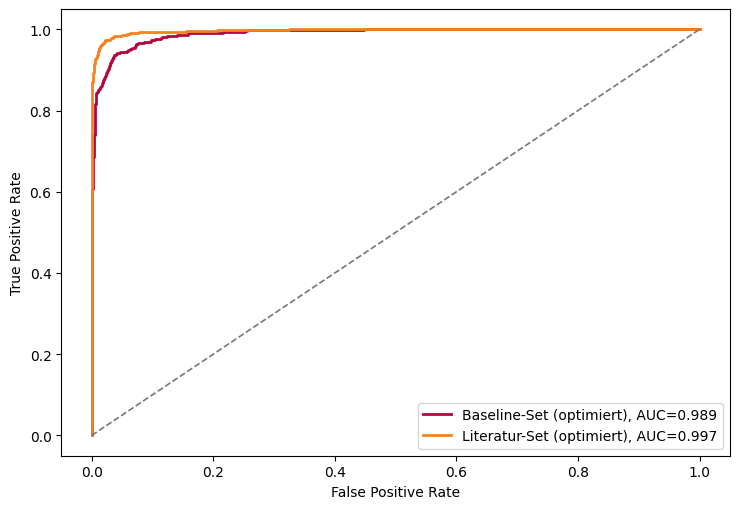

In [48]:
plt.figure(figsize=(7.5, 5.2))

plt.plot(
    fpr_b, tpr_b,
    label=f"Baseline-Set (optimiert), AUC={auc_base:.3f}",
    color="#B1073A", linewidth=2
)

plt.plot(
    fpr_v, tpr_v,
    label=f"Literatur-Set (optimiert), AUC={auc_v2:.3f}",
    color="#F58220", linewidth=2
)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2, color="#777777")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_comparison_v2.png", dpi=300, bbox_inches="tight")
plt.show()

## Permutation Importance

In [49]:
perm_base = permutation_importance(
    rf_base,
    X_base_df.values,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="roc_auc"
)

perm_v2 = permutation_importance(
    rf_v2,
    X_v2_df.values,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="roc_auc"
)

imp_base = pd.DataFrame({
    "feature": X_base_df.columns,
    "importance_mean": perm_base.importances_mean,
    "importance_std": perm_base.importances_std
}).sort_values("importance_mean", ascending=False)

imp_v2 = pd.DataFrame({
    "feature": X_v2_df.columns,
    "importance_mean": perm_v2.importances_mean,
    "importance_std": perm_v2.importances_std
}).sort_values("importance_mean", ascending=False)

display(imp_base.head(8))
display(imp_v2.head(8))

,feature,importance_mean,importance_std
7,spec_entropy_ch0,0.077737,0.001669
15,spec_entropy_ch1,0.019551,0.001144
5,dom_freq_ch0,0.007998,0.000638
13,dom_freq_ch1,0.003456,0.000406
12,zcr_ch1,0.000481,0.000151
0,mean_ch0,0.000115,0.000028
3,ptp_ch0,0.000101,0.000251
16,corr_ch0_ch1,0.000068,0.000343


,feature,importance_mean,importance_std
5,tcsc,0.007667,0.000573
6,vfleak,0.005861,0.000410
0,bcp,0.004039,0.000226
7,sampen,0.001947,0.000197
2,x2,0.001864,0.000216
3,x3_domfreq_1_10,0.001162,0.000244
1,x1,0.000882,0.000167
4,x4_bandpower_2p5_7p5,0.000807,0.000192


In [50]:
HPI_ORANGE = "#F58220"

def plot_perm_importance_uniform(
    df,
    filename,
    topk=8,
    color=HPI_ORANGE,
    figsize=(8.5, 3.2),
    rename_map=None
):
    df_top = df.head(topk).copy()

    if rename_map:
        df_top["feature_display"] = df_top["feature"].replace(rename_map)
    else:
        df_top["feature_display"] = df_top["feature"]

    df_top = df_top.iloc[::-1]

    fig, ax = plt.subplots(figsize=figsize)

    ax.barh(
        df_top["feature_display"],
        df_top["importance_mean"],
        xerr=df_top["importance_std"],
        color=color,
        alpha=0.95
    )

    ax.set_xlabel("Permutation Importance (Δ ROC-AUC)")
    ax.set_xlim(left=0.0)
    ax.margins(x=0)
    ax.grid(False)

    fig.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

## Plots

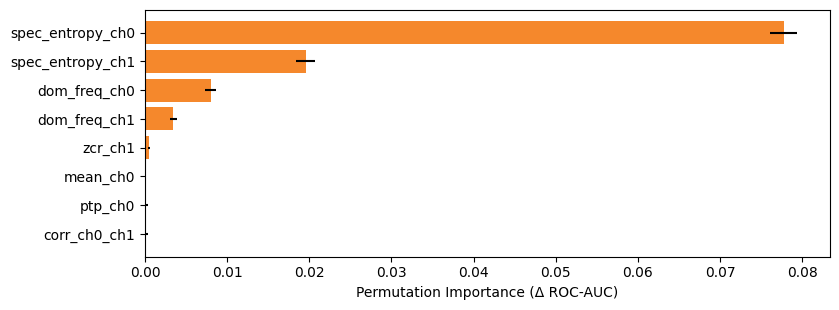

In [51]:
plot_perm_importance_uniform(
    imp_base,
    filename="03_perm_importance_baseline_opt.png",
    topk=8,
    figsize=(8.5, 3.2)
)

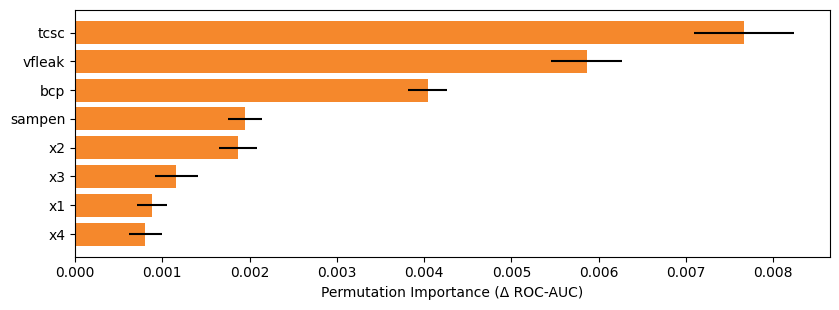

In [52]:
rename_v2 = {
    "x3_domfreq_1_10": "x3",
    "x4_bandpower_2p5_7p5": "x4"
}

plot_perm_importance_uniform(
    imp_v2,
    filename="04_perm_importance_v2_opt.png",
    topk=8,
    figsize=(8.5, 3.2),
    rename_map=rename_v2
)